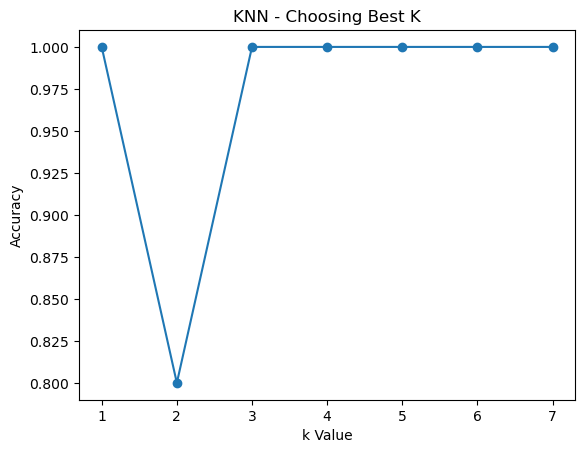

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Load dataset
dataset = pd.read_csv("KNN_customers.csv")

x = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

#Train-test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=0)

#Scaling (important even for 0/1 values)
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

#K tuning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

accuracy_list = []
k_values = range(1, 8)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    accuracy_list.append(accuracy_score(y_test, y_pred))

#plot
plt.plot(k_values, accuracy_list, marker='o')
plt.xlabel("k Value")
plt.ylabel("Accuracy")
plt.title("KNN - Choosing Best K")
plt.show()
